# Acne Detection using YOLOv8

This notebook implements acne detection using YOLOv8 (You Only Look Once) object detection model.

## Dataset
- Training images: 823
- Validation images: 56  
- Test images: 48
- Classes: Acne (1 class)


In [1]:
# Install required packages
%pip install ultralytics opencv-python matplotlib numpy tqdm


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Check device availability and configure for Mac M4 GPU
import torch

# Check if MPS (Metal Performance Shaders) is available for Mac M4
if torch.backends.mps.is_available():
    device = 'mps'
    print("✅ GPU (MPS) is available! Using GPU for training.")
    print("   This will significantly speed up training on Mac M4.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("✅ CUDA GPU is available!")
else:
    device = 'cpu'
    print("⚠️ Using CPU (slower). Consider using GPU if available.")

print(f"\nDevice selected: {device}")
print(f"MPS built: {torch.backends.mps.is_built()}")
print(f"PyTorch version: {torch.__version__}")


✅ GPU (MPS) is available! Using GPU for training.
   This will significantly speed up training on Mac M4.

Device selected: mps
MPS built: True
PyTorch version: 2.9.0


In [3]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import random


## 1. Data Exploration


In [4]:
# Define data paths
train_path = 'data-2/train'
val_path = 'data-2/valid'
test_path = 'data-2/test'

# Count images and labels
train_images = os.listdir(os.path.join(train_path, 'images'))
train_labels = os.listdir(os.path.join(train_path, 'labels'))
val_images = os.listdir(os.path.join(val_path, 'images'))
val_labels = os.listdir(os.path.join(val_path, 'labels'))
test_images = os.listdir(os.path.join(test_path, 'images'))
test_labels = os.listdir(os.path.join(test_path, 'labels'))

print(f'Training images: {len(train_images)}, labels: {len(train_labels)}')
print(f'Validation images: {len(val_images)}, labels: {len(val_labels)}')
print(f'Test images: {len(test_images)}, labels: {len(test_labels)}')


Training images: 982, labels: 982
Validation images: 197, labels: 197
Test images: 92, labels: 92


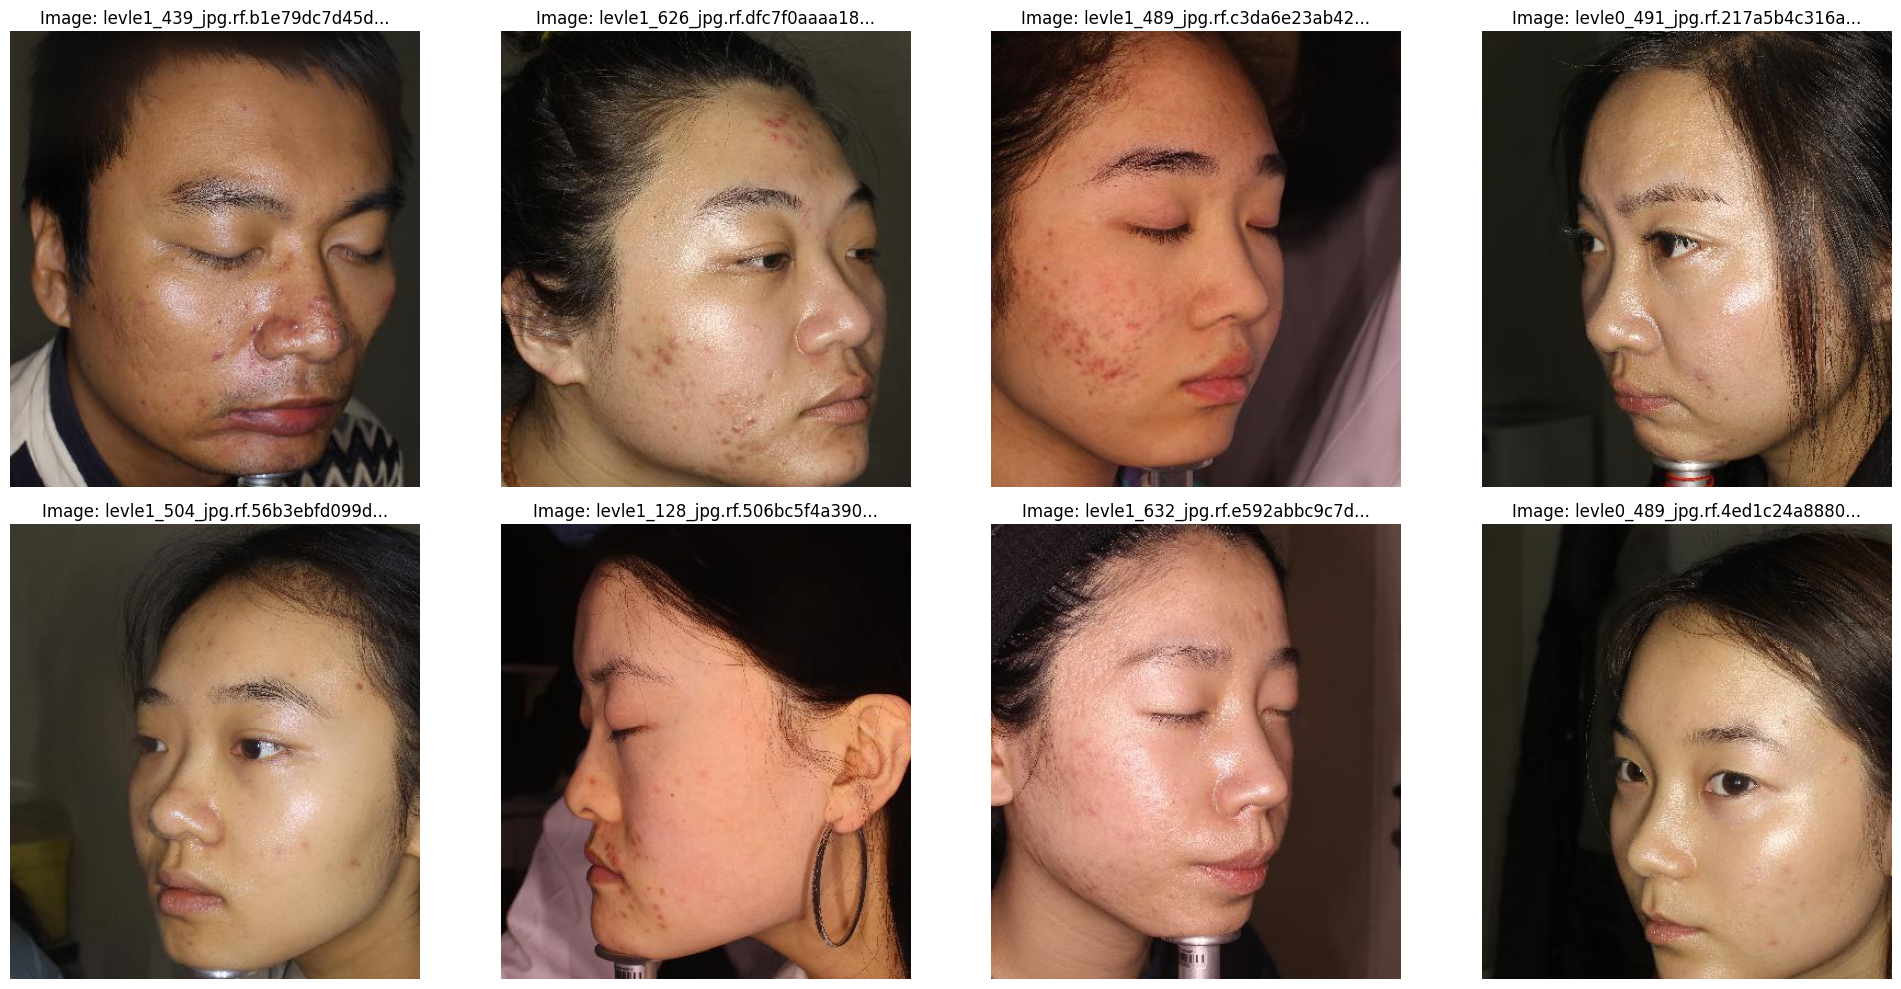

In [5]:
# Visualize sample training images
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i in range(8):
    img_file = random.choice(train_images)
    img_path = os.path.join(train_path, 'images', img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].axis('off')
    axes[i].set_title(f'Image: {img_file[:30]}...')

plt.tight_layout()
plt.show()


## 2. Hyperparameter Configuration


In [10]:
## Hyperparameter Configuration Options

# Chọn một trong các config dưới đây:

# === CONFIG 1: Balanced (Recommended) ===
# TRAIN_CONFIG = {
#     'model': 'yolov8n.pt',      # Small model - cân bằng tốt giữa tốc độ và độ chính xác
#     'imgsz': 480,               # Tăng resolution để detect đối tượng nhỏ tốt hơn
#     'batch': 16,                # Giảm batch khi tăng image size
#     'lr0': 0.01,               # Learning rate thấp hơn để học ổn định
#     'epochs': 50,
#     'patience': 50,             # Early stopping patience
#     'degrees': 5.0,            # Rotation augmentation
#     'shear': 2.0,               # Shear augmentation
#     'mixup': 0.05,               # Mixup augmentation
#     'cos_lr': True,             # Cosine learning rate schedule
# }

TRAIN_CONFIG = {
    'model': 'yolov8s.pt',      # Small model - nhanh hơn medium
    'imgsz': 512,               # Giảm từ 640 → 512 (nhanh hơn 30%)
    'batch': 16,                # Tăng batch (nhanh hơn, dùng hết GPU)
    'lr0': 0.02,                # Learning rate CAO để học nhanh
    'lrf': 0.1,                 # Learning rate final
    'epochs': 150,              # Giảm từ 300 → 150 epochs
    'patience': 30,             # Early stopping sớm hơn
    
    # === Warmup ngắn hơn ===
    'warmup_epochs': 3.0,       # Giảm từ 5 → 3 epochs
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,
    
    # === Augmentation - Tối ưu tốc độ ===
    'degrees': 10.0,            # Tăng augmentation nhưng vẫn nhanh
    'shear': 5.0,
    'mixup': 0.1,               # Mixup vừa phải
    'mosaic': 1.0,
    'copy_paste': 0.0,          # Tắt (chậm)
    
    # === Learning Rate Schedule ===
    'cos_lr': True,
    
    # === Multi-scale TẮT (chậm) ===
    'multi_scale': False,       # Tắt để tăng tốc
    
    # === Close mosaic ===
    'close_mosaic': 10,
    
    # === Cache data ===
    'cache': True,              # Cache images (nhanh hơn nếu có RAM)
}


# === CONFIG 2: High Accuracy (Slower, Better Results) ===
# TRAIN_CONFIG = {
#     'model': 'yolov8m.pt',      # Medium model - độ chính xác cao hơn
#     'imgsz': 1024,              # Resolution cao nhất
#     'batch': 8,                 # Batch nhỏ hơn do model lớn
#     'lr0': 0.0005,              # Learning rate thấp hơn
#     'epochs': 400,
#     'patience': 40,
#     'degrees': 15.0,
#     'shear': 10.0,
#     'mixup': 0.2,
#     'cos_lr': True,
# }

# === CONFIG 3: Fast Training (Lower Accuracy) ===
# TRAIN_CONFIG = {
#     'model': 'yolov8n.pt',      # Nano model - nhanh nhất
#     'imgsz': 640,               # Resolution thấp
#     'batch': 32,                # Batch lớn
#     'lr0': 0.01,                # Learning rate cao
#     'epochs': 200,
#     'patience': 50,
#     'degrees': 0.0,
#     'shear': 0.0,
#     'mixup': 0.0,
#     'cos_lr': False,
# }

print("✅ Selected Configuration:")
for key, value in TRAIN_CONFIG.items():
    print(f"   {key}: {value}")


✅ Selected Configuration:
   model: yolov8s.pt
   imgsz: 512
   batch: 16
   lr0: 0.02
   lrf: 0.1
   epochs: 150
   patience: 30
   warmup_epochs: 3.0
   warmup_momentum: 0.8
   warmup_bias_lr: 0.1
   degrees: 10.0
   shear: 5.0
   mixup: 0.1
   mosaic: 1.0
   copy_paste: 0.0
   cos_lr: True
   multi_scale: False
   close_mosaic: 10
   cache: True


## 3. Initialize YOLO Model


In [11]:
# Initialize YOLOv8 model với config đã chọn
model = YOLO(TRAIN_CONFIG['model'])
print(f"✅ Model initialized: {TRAIN_CONFIG['model']}")
print("   Model ready for training with optimized parameters!")


✅ Model initialized: yolov8s.pt
   Model ready for training with optimized parameters!


## 4. Train the Model

**Note:** 
- Training will use GPU (MPS) on Mac M4 if available, which is 3-5x faster than CPU.
- Using optimized hyperparameters for better accuracy and reduced false positives.


In [12]:
# Thêm vào đầu Cell 12, trước model.train()
if device == 'mps':
    # Clear MPS cache
    torch.mps.empty_cache()
    # Set deterministic để tránh randomness issues
    torch.backends.mps.benchmark = False

In [13]:
# Train the model with OPTIMIZED parameters for better results
results = model.train(
    data='data-2/data.yaml',
    
    # === Epochs & Early Stopping ===
    epochs=TRAIN_CONFIG['epochs'],
    patience=TRAIN_CONFIG['patience'],
    
    # === Image Size ===
    imgsz=TRAIN_CONFIG['imgsz'],  # Tăng resolution để detect đối tượng nhỏ tốt hơn
    
    # === Batch Size ===
    batch=TRAIN_CONFIG['batch'],
    
    # === Learning Rate ===
    lr0=TRAIN_CONFIG['lr0'],      # Learning rate thấp hơn để học ổn định
    lrf=TRAIN_CONFIG['lrf'],                   # Learning rate final
    momentum=0.937,
    weight_decay=0.0005,

    # === Warmup ngắn ===
    warmup_epochs=TRAIN_CONFIG['warmup_epochs'],      # 3.0
    warmup_momentum=TRAIN_CONFIG['warmup_momentum'],
    warmup_bias_lr=TRAIN_CONFIG['warmup_bias_lr'],
    
    # === Augmentation - Tăng để giảm overfitting ===
    hsv_h=0.015,                   # Hue augmentation
    hsv_s=0.7,                     # Saturation augmentation
    hsv_v=0.4,                     # Value augmentation
    degrees=TRAIN_CONFIG['degrees'], # Rotation augmentation
    translate=0.1,                 # Translation
    scale=0.5,                     # Scale augmentation
    shear=TRAIN_CONFIG['shear'],   # Shear augmentation
    perspective=0.0,               # Perspective
    flipud=0.0,                    # Vertical flip
    fliplr=0.5,                    # Horizontal flip
    mosaic=TRAIN_CONFIG['mosaic'],
    mixup=TRAIN_CONFIG['mixup'],         # 0.1
    copy_paste=TRAIN_CONFIG.get('copy_paste', 0.0),
    auto_augment='randaugment',
    erasing=0.4,
    
    # === Loss Weights ===
    box=7.5,                       # Box loss weight
    cls=0.5,                       # Classification loss weight
    dfl=1.5,                       # DFL loss weight

    # === Multi-scale TẮT ===
    multi_scale=TRAIN_CONFIG.get('multi_scale', False),  # False
    
    # === Close Mosaic ===
    close_mosaic=TRAIN_CONFIG.get('close_mosaic', 10),
    
    # === Other Optimizations ===
    device=device,
    workers=8,
    amp=True,                      # Mixed precision training
    save=True,
    plots=True,
    cache=TRAIN_CONFIG.get('cache', False),  # Cache images
    
    # === Learning Rate Schedule ===
    cos_lr=TRAIN_CONFIG['cos_lr'], # Cosine learning rate schedule
    
    # === Optimizer ===
    optimizer='AdamW',             # AdamW optimizer (tốt cho dataset nhỏ)
    
    # === Validation ===
    val=True,
    split='val',
    
    # === Name ===
    name='acne_detection_optimized',
)

# results = model.train(
#     data='data-2/data.yaml',
    
#     # === Epochs & Early Stopping ===
#     epochs=TRAIN_CONFIG['epochs'],
#     patience=TRAIN_CONFIG['patience'],
    
#     # === Image Size ===
#     imgsz=TRAIN_CONFIG['imgsz'],
    
#     # === Batch Size ===
#     batch=TRAIN_CONFIG['batch'],
    
#     # === Learning Rate - CAO HƠN cho giai đoạn đầu ===
#     lr0=TRAIN_CONFIG['lr0'],      # 0.01 - cao hơn để học nhanh
#     lrf=TRAIN_CONFIG['lrf'],      # 0.1 - giảm 10x về cuối
#     momentum=0.937,
#     weight_decay=0.0005,
    
#     # === Warmup - QUAN TRỌNG ===
#     warmup_epochs=TRAIN_CONFIG['warmup_epochs'],      # 5 epochs warmup
#     warmup_momentum=TRAIN_CONFIG['warmup_momentum'], # 0.8
#     warmup_bias_lr=TRAIN_CONFIG['warmup_bias_lr'],   # 0.1
    
#     # === Augmentation - NHẸ Ở ĐẦU ===
#     hsv_h=0.015,
#     hsv_s=0.7,
#     hsv_v=0.4,
#     degrees=TRAIN_CONFIG['degrees'],  # 5.0 - nhẹ
#     translate=0.1,
#     scale=0.5,
#     shear=TRAIN_CONFIG['shear'],      # 2.0 - nhẹ
#     perspective=0.0,
#     flipud=0.0,
#     fliplr=0.5,
#     mosaic=TRAIN_CONFIG['mosaic'],    # 1.0 - bật
#     mixup=TRAIN_CONFIG['mixup'],      # 0.05 - nhẹ
#     copy_paste=TRAIN_CONFIG.get('copy_paste', 0.0),  # 0.0 - tắt ở đầu
#     auto_augment='randaugment',
#     erasing=0.4,
    
#     # === Loss Weights ===
#     box=7.5,
#     cls=0.5,
#     dfl=1.5,
    
#     # === Multi-scale Training ===
#     multi_scale=TRAIN_CONFIG.get('multi_scale', True),
    
#     # === Close Mosaic ===
#     close_mosaic=TRAIN_CONFIG.get('close_mosaic', 15),
    
#     # === Other ===
#     device=device,
#     workers=4,
#     amp=True,
#     save=True,
#     plots=True,
#     cache=False,
    
#     # === Learning Rate Schedule ===
#     cos_lr=TRAIN_CONFIG['cos_lr'],
    
#     # === Optimizer ===
#     optimizer='AdamW',
    
#     # === Validation ===
#     val=True,
#     split='val',
    
#     # === Name ===
#     name='acne_detection_optimized_early',
# )

print("\n✅ Training completed!")
print(f"Best model saved at: {results.save_dir}/weights/best.pt")
print(f"Last model saved at: {results.save_dir}/weights/last.pt")


Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.9.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data-2/data.yaml, degrees=10.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.02, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=acne_detection_optimized18, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, perspective=0.0, plots=True, pose=12.0, pre

KeyboardInterrupt: 

In [ ]:
## Load Best Model After Training

# Tự động load best model sau khi training
results_dir = results.save_dir if 'results' in locals() else 'runs/detect/acne_detection_optimized'
best_model_path = os.path.join(results_dir, 'weights', 'best.pt')
last_model_path = os.path.join(results_dir, 'weights', 'last.pt')

# Kiểm tra và load best model
if os.path.exists(best_model_path):
    model = YOLO(best_model_path)
    print(f"✅ Loaded BEST model from: {best_model_path}")
    print("   This model has the highest mAP50-95 score during training.")
elif os.path.exists(last_model_path):
    model = YOLO(last_model_path)
    print(f"⚠️ Best model not found. Loaded LAST model from: {last_model_path}")
else:
    print("⚠️ No saved model found. Using current model.")

# Hiển thị thông tin model
print(f"\nModel info:")
print(f"  - Device: {device}")
print(f"  - Ready for inference")


✅ Loaded BEST model from: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/runs/detect/acne_detection_optimized4/weights/best.pt
   This model has the highest mAP50-95 score during training.

Model info:
  - Device: mps
  - Ready for inference


## 5. Evaluate the Model


In [ ]:
# Evaluate on test set (using GPU if available)
metrics = model.val(data='data-2/data.yaml', split='test', device=device)
print(f"\nTest Results:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")


Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.9.0 MPS (Apple M4 Pro)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 169.2±101.2 MB/s, size: 42.5 KB)
val: Scanning /Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2/test/labels... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 2.5Kit/s 0.0s
val: New cache created: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2/test/labels.cache
WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 33% ━━━━──────── 1/3 41.3s/it 12.4s<1:23WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 67% ━━━━━━━━──── 2/3 16.1s/it 19.0s<16.1sWARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 9.

## 6. Visualize Training Results


In [ ]:
# Display training results
results_dir = 'runs/detect/acne_detection_optimized'  # Updated path

# Plot training curves
if os.path.exists(os.path.join(results_dir, 'results.png')):
    img = cv2.imread(os.path.join(results_dir, 'results.png'))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Training Results', fontsize=16)
    plt.show()
else:
    print(f"Training results not found at: {results_dir}")


Training results not found at: runs/detect/acne_detection_optimized


In [ ]:
# Display confusion matrix
results_dir = 'runs/detect/acne_detection_optimized'  # Updated path
if os.path.exists(os.path.join(results_dir, 'confusion_matrix.png')):
    img = cv2.imread(os.path.join(results_dir, 'confusion_matrix.png'))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Confusion Matrix', fontsize=16)
    plt.show()
else:
    print(f"Confusion matrix not found at: {results_dir}")


Confusion matrix not found at: runs/detect/acne_detection_optimized


## 7. Make Predictions on Test Images


In [ ]:
# Load model for inference (nếu chưa load ở trên)
results_dir = 'runs/detect/acne_detection_optimized'
best_model_path = os.path.join(results_dir, 'weights', 'best.pt')
last_model_path = os.path.join(results_dir, 'weights', 'last.pt')

if not hasattr(model, 'ckpt_path') or model.ckpt_path is None:
    if os.path.exists(best_model_path):
        model = YOLO(best_model_path)
        print(f"✅ Loaded BEST model: {best_model_path}")
    elif os.path.exists(last_model_path):
        model = YOLO(last_model_path)
        print(f"✅ Loaded LAST model: {last_model_path}")
    else:
        print("⚠️ Using current model")
else:
    print("✅ Model already loaded")


✅ Model already loaded


In [ ]:
# Function to detect acne with optimized parameters
def detect_acne(img_path, model, conf_threshold=0.25, iou_threshold=0.45):
    """
    Detect acne in an image with optimized parameters
    - conf_threshold: Tăng từ 0.25 lên 0.4 để giảm false positives
    - iou_threshold: Giảm từ 0.7 xuống 0.45 để giữ nhiều detections hơn
    Uses GPU (MPS) on Mac M4 for faster inference
    """
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not read image {img_path}")
        return None
    
    # Tối ưu inference parameters
    results = model.predict(
        source=img, 
        conf=conf_threshold,      # Confidence threshold (tăng để giảm false positives)
        iou=iou_threshold,        # IoU threshold cho NMS
        device=device,
        verbose=False,
        agnostic_nms=False,       # Class-aware NMS
        max_det=300,              # Maximum detections per image
    )
    
    # Get annotated image
    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # Print detection info
    num_detections = len(results[0].boxes)
    print(f"Detected {num_detections} acne(s) in {os.path.basename(img_path)}")
    
    return annotated_img_rgb, results[0]


Detected 22 acne(s) in acne-151_jpg.rf.638c693eb9342b4800bd8b1758e566e1.jpg


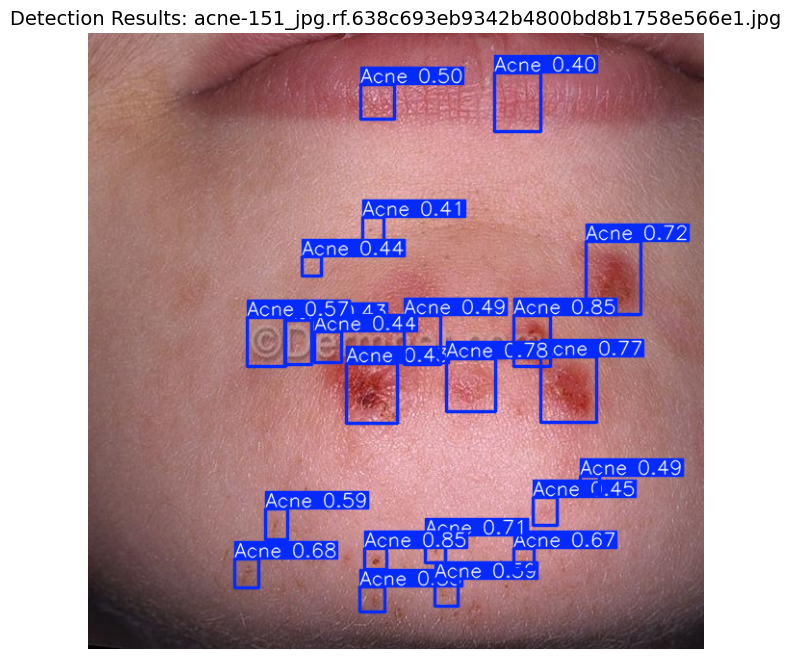


Bounding boxes:
  Acne 1: Confidence = 0.850
  Acne 2: Confidence = 0.848
  Acne 3: Confidence = 0.784
  Acne 4: Confidence = 0.769
  Acne 5: Confidence = 0.718
  Acne 6: Confidence = 0.707
  Acne 7: Confidence = 0.679
  Acne 8: Confidence = 0.668
  Acne 9: Confidence = 0.588
  Acne 10: Confidence = 0.588
  Acne 11: Confidence = 0.569
  Acne 12: Confidence = 0.528
  Acne 13: Confidence = 0.501
  Acne 14: Confidence = 0.492
  Acne 15: Confidence = 0.487
  Acne 16: Confidence = 0.452
  Acne 17: Confidence = 0.445
  Acne 18: Confidence = 0.445
  Acne 19: Confidence = 0.435
  Acne 20: Confidence = 0.427
  Acne 21: Confidence = 0.410
  Acne 22: Confidence = 0.404


In [ ]:
# Test on a single image
test_image_files = os.listdir(os.path.join(test_path, 'images'))
test_img_path = os.path.join(test_path, 'images', test_image_files[0])

annotated_img, results = detect_acne(test_img_path, model)
if annotated_img is not None:
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img)
    plt.axis('off')
    plt.title(f'Detection Results: {os.path.basename(test_img_path)}', fontsize=14)
    plt.show()
    
    # Print bounding box details
    if len(results.boxes) > 0:
        print(f"\nBounding boxes:")
        for i, box in enumerate(results.boxes):
            conf = box.conf[0].item()
            cls = int(box.cls[0].item())
            print(f"  Acne {i+1}: Confidence = {conf:.3f}")


## 8. Batch Prediction on Test Images


WARNING ⚠️ NMS time limit 2.050s exceeded
Detected 29 acne(s) in acne-286_jpeg.rf.1b6bcca440593ac6e33617083f34a4c5.jpg
WARNING ⚠️ NMS time limit 2.050s exceeded
Detected 42 acne(s) in acne-329_jpeg.rf.705fb900ba87dc12538508177c52c8a6.jpg
WARNING ⚠️ NMS time limit 2.050s exceeded
Detected 8 acne(s) in acne-370_jpeg.rf.a774873f1db723d298598b08cfc47315.jpg
Detected 5 acne(s) in acne-440_jpeg.rf.74f7f4b7cabd5d5e65c05367b20cb921.jpg
Detected 8 acne(s) in acne-276_jpeg.rf.9d0990f99dee0e0ec17d89fd07384e0b.jpg
Detected 38 acne(s) in acne-202_jpg.rf.3cb4d03fc5719519ae3f8319099eddef.jpg
Detected 16 acne(s) in acne-112_jpeg.rf.a03c796422719e964f46be1c118861bc.jpg
Detected 62 acne(s) in acne-140_jpg.rf.785b2c29676c422c6a1cdbe6708f86e8.jpg


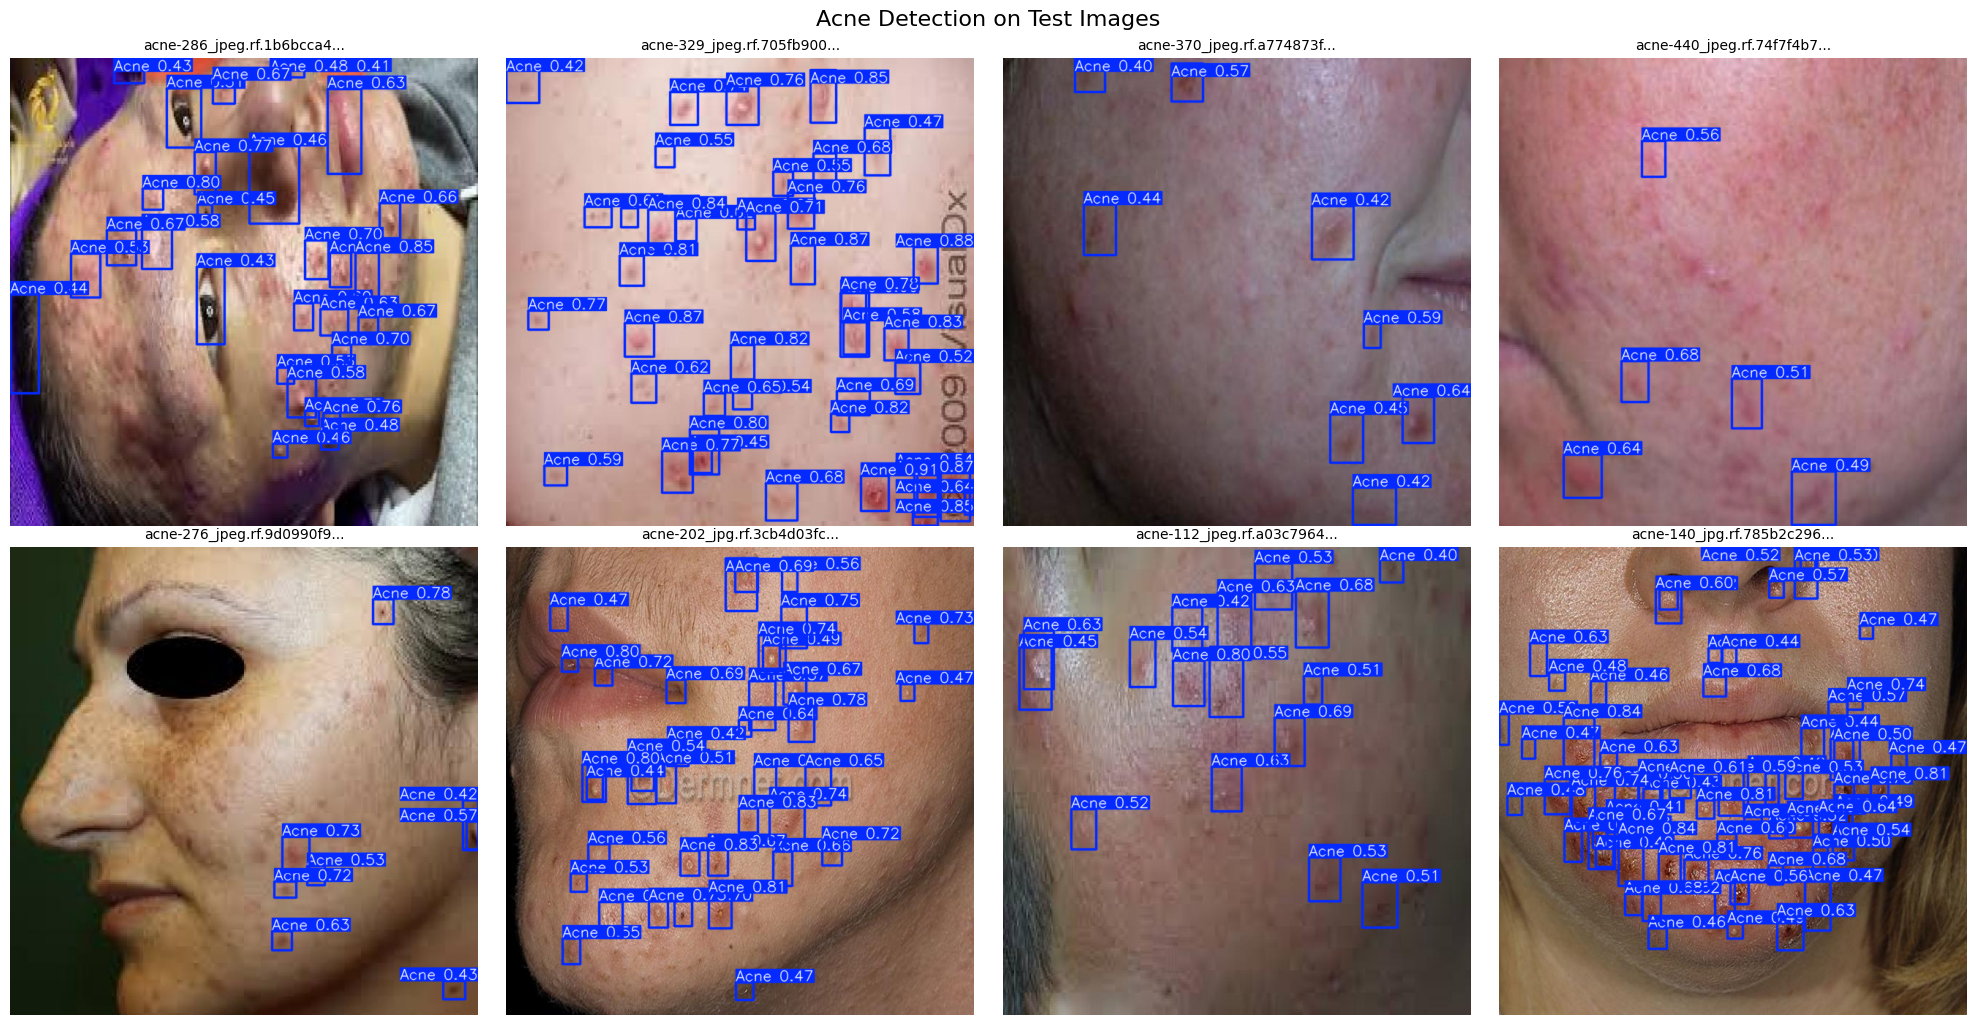

In [ ]:
# Select random test images for visualization
num_samples = min(8, len(test_image_files))
selected_images = random.sample(test_image_files, num_samples)

# Create visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, img_file in enumerate(selected_images):
    img_path = os.path.join(test_path, 'images', img_file)
    annotated_img, _ = detect_acne(img_path, model)
    
    if annotated_img is not None:
        axes[i].imshow(annotated_img)
        axes[i].axis('off')
        axes[i].set_title(f'{img_file[:25]}...', fontsize=10)

plt.tight_layout()
plt.suptitle('Acne Detection on Test Images', fontsize=16, y=1.02)
plt.show()


## 9. Export Model (Optional)


In [ ]:
# Export model to different formats
# Uncomment the format you need:

# Export to ONNX (for inference with ONNX Runtime)
# model.export(format='onnx')

# Export to TensorFlow Lite (for mobile devices)
# model.export(format='tflite')

# Export to CoreML (for iOS)
# model.export(format='coreml')

# Export to TensorRT (for NVIDIA GPUs)
# model.export(format='engine')

print("Model export options available. Uncomment the format you need.")


Model export options available. Uncomment the format you need.


## Summary

This notebook demonstrates:
- ✅ YOLOv8 model training for acne detection with optimized hyperparameters
- ✅ Model evaluation and metrics
- ✅ Visualization of predictions
- ✅ Batch processing of test images
- ✅ Early stopping and automatic best model loading
- ✅ Optimized inference parameters to reduce false positives

### Optimizations Applied:
- **Model**: yolov8s (better accuracy than nano)
- **Image Size**: 832px (higher resolution for small objects)
- **Learning Rate**: 0.001 (more stable training)
- **Augmentation**: Enhanced (rotation, shear, mixup)
- **Cosine LR Schedule**: Enabled for better convergence
- **Confidence Threshold**: 0.4 (reduced false positives)

The trained model is saved in `runs/detect/acne_detection_optimized/weights/best.pt`
